# Project 2: Medical Route Optimization

This notebook demonstrates the Genetic Algorithm solution for the Vehicle Routing Problem (VRP) in a medical delivery context.

In [7]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import random
from src.models.location import Location
from src.models.vehicle import Vehicle
from src.algorithms.genetic_optimizer import GeneticOptimizer
from src.utils.plotter import Plotter
from src.llm.report_generator import ReportGenerator
from src.utils.data_loader import DataLoader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# 1. Define Problem Data
depot = Location(0, 50, 50, "Central Depot", type='depot')

NUM_LOCATIONS = 50

locations = DataLoader.load_data(limit=NUM_LOCATIONS, data_dir='../data')

# Create Fleet
# Estimate required capacity
deliveries = [l for l in locations if getattr(l, 'type', 'delivery') == 'delivery']
total_demand = sum(l.demand for l in deliveries)
num_vehicles = 10

fleet = []
total_capacity = 0
total_distance = 0
for i in range(num_vehicles):
    capacity = random.randint(3, 6)
    total_capacity += capacity
    max_distance = random.randint(100, 200)
    total_distance += max_distance
    fleet.append(Vehicle(id=i+1, capacity=capacity, max_distance=max_distance))

print(f"Loaded {NUM_LOCATIONS} locations from dataset and {len(locations) - NUM_LOCATIONS} gas stations.")
print(f"Created Fleet of {len(fleet)} vehicles with total load capacity of {total_capacity} and total autonomy distance of {total_distance}")
print("Fleet: ")
for vehicle in fleet:
    print(f"Vehicle {vehicle.id} has a capacity of {vehicle.capacity} and a max distance of {vehicle.max_distance}")

Loaded 50 locations from dataset and 10 gas stations.
Created Fleet of 10 vehicles with total load capacity of 43 and total autonomy distance of 1337
Fleet: 
Vehicle 1 has a capacity of 4 and a max distance of 102
Vehicle 2 has a capacity of 4 and a max distance of 135
Vehicle 3 has a capacity of 4 and a max distance of 123
Vehicle 4 has a capacity of 5 and a max distance of 183
Vehicle 5 has a capacity of 5 and a max distance of 163
Vehicle 6 has a capacity of 4 and a max distance of 138
Vehicle 7 has a capacity of 4 and a max distance of 117
Vehicle 8 has a capacity of 3 and a max distance of 141
Vehicle 9 has a capacity of 5 and a max distance of 133
Vehicle 10 has a capacity of 5 and a max distance of 102


In [ ]:
# 2. Run Genetic Algorithm
# Adjust generations/pop_size based on problem size if needed
generations = 2000 
pop_size = 60
early_stopping_rounds = 25


optimizer = GeneticOptimizer(locations, depot, fleet, generations=generations, pop_size=pop_size, early_stopping_rounds=early_stopping_rounds, priority_weight=0.5)
best_routes, best_dist, fitness_history = optimizer.run()

print(f"Best Total Distance: {best_dist:.2f}")

Stopping early at generation 364 due to no improvement for 25 rounds.
Best Total Distance: 1539.09


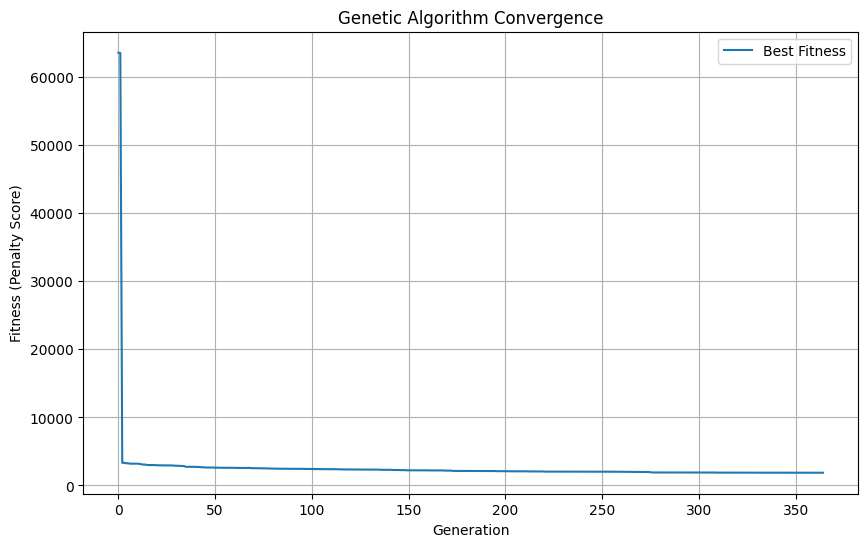

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(fitness_history, label='Best Fitness')
plt.title('Genetic Algorithm Convergence')
plt.xlabel('Generation')
plt.ylabel('Fitness (Penalty Score)')
plt.grid(True)
plt.legend()
plt.show()

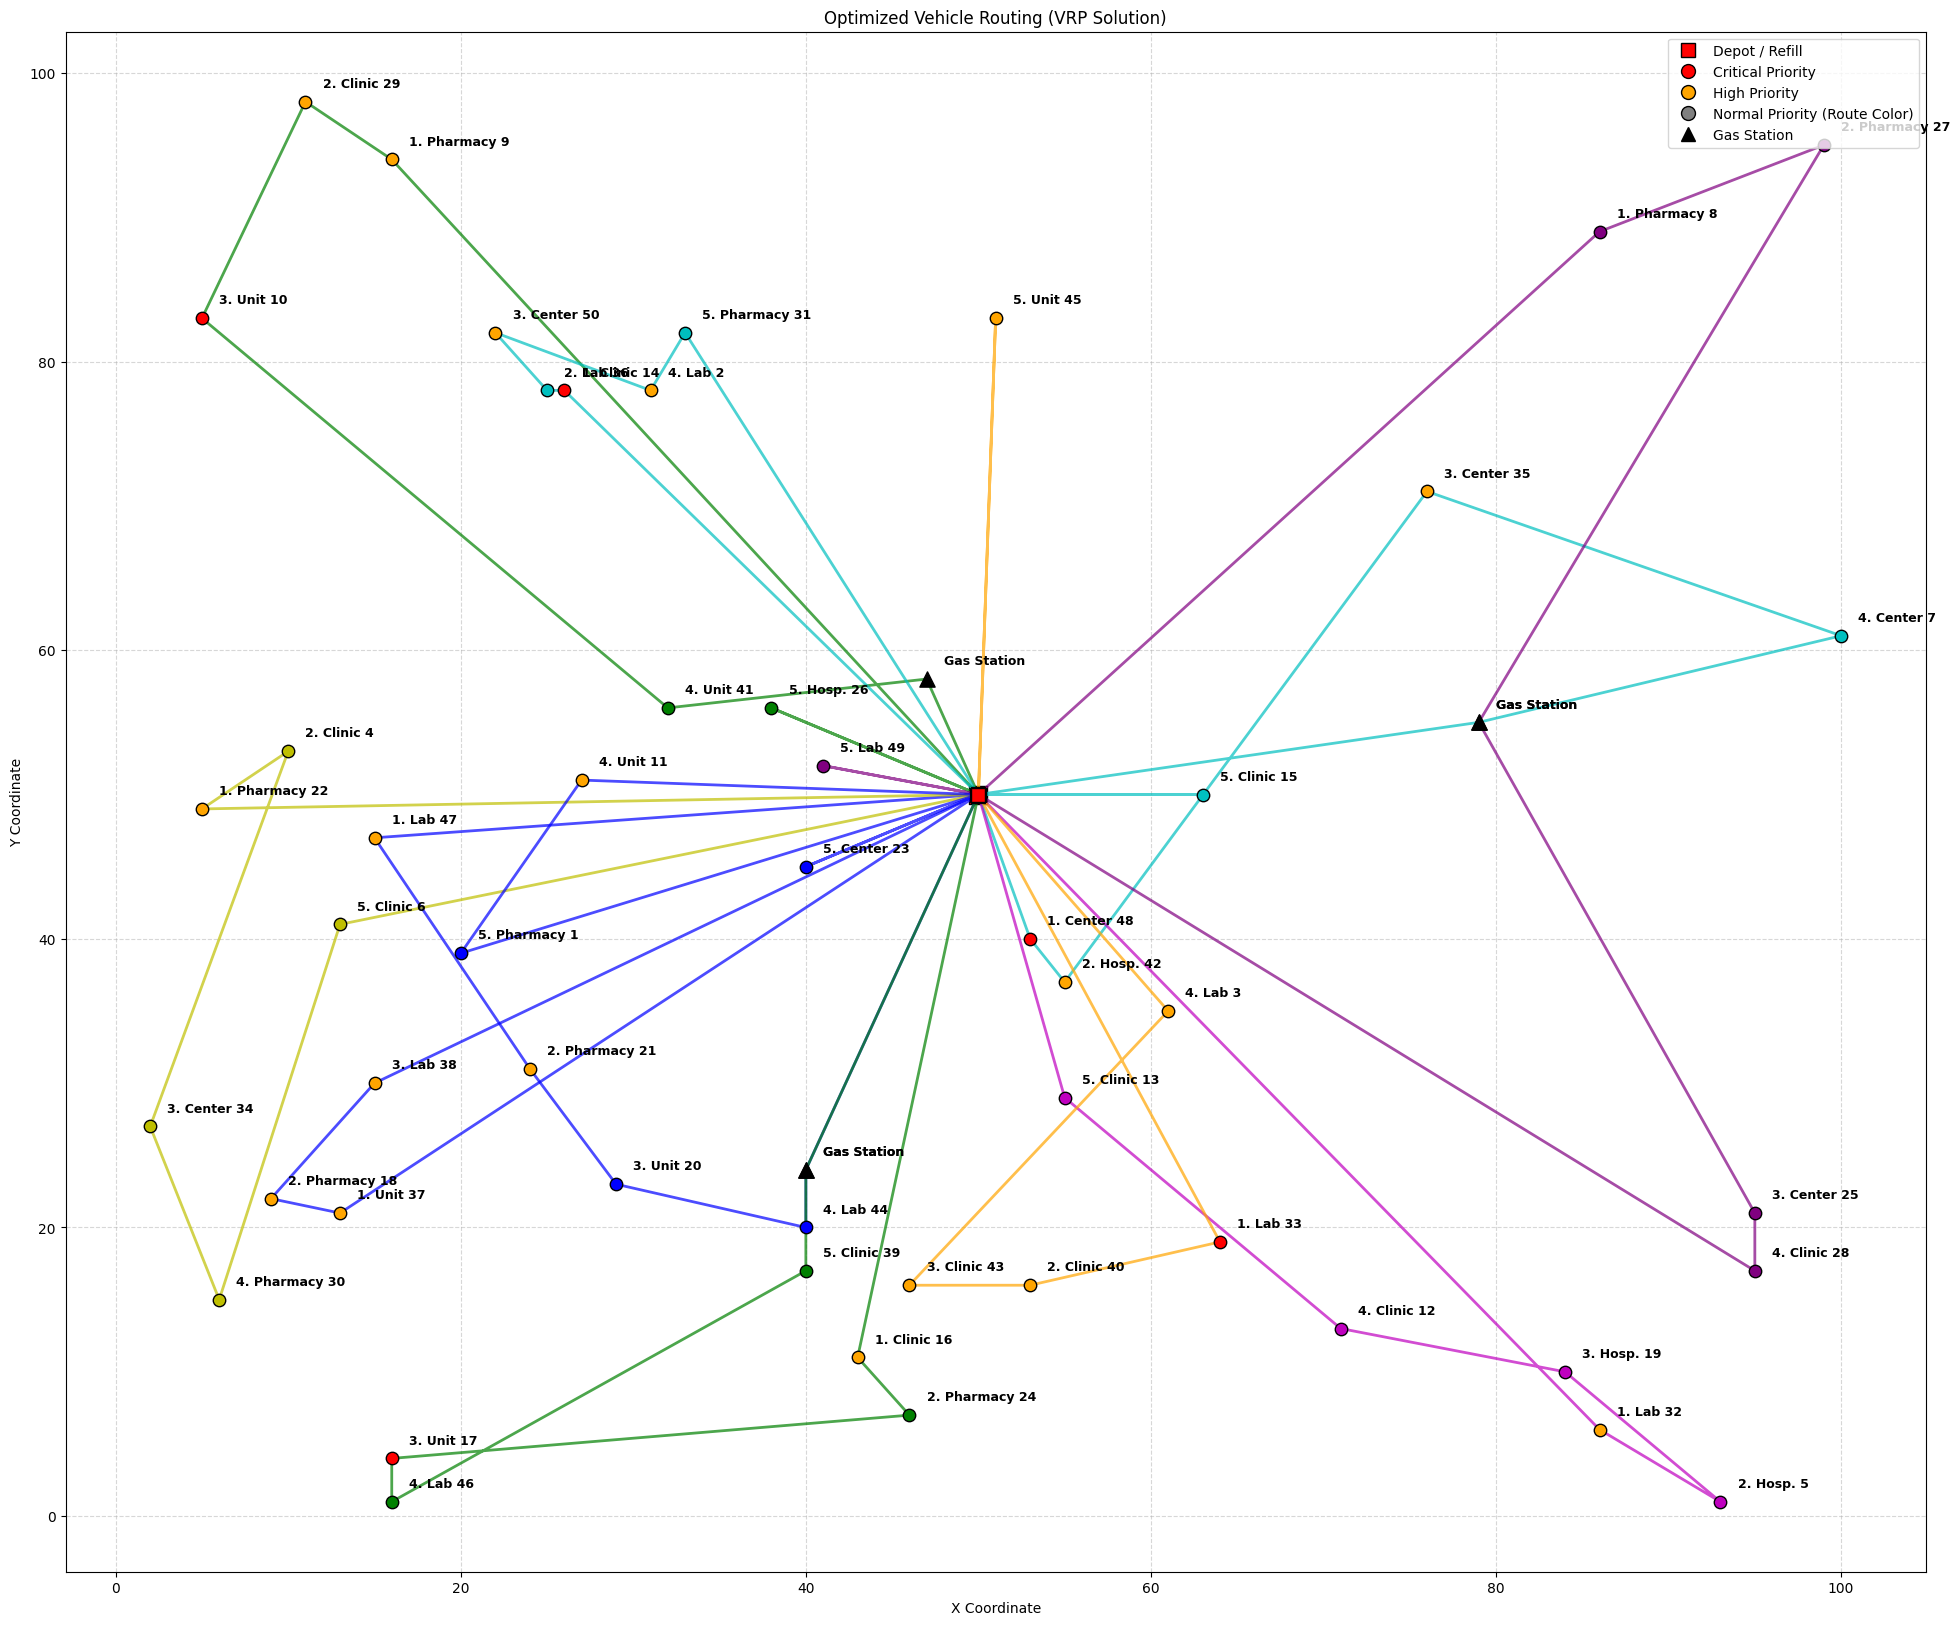

In [39]:
# 3. Visualize Solution
Plotter.plot_solution(best_routes, depot)

In [12]:
# 4. Generate LLM Report
llm = ReportGenerator() # Will use mock if no API key

print("Generating Instructions for Drivers...\n")

# Limit output for large datasets to avoid spamming the notebook
max_reports = 3 if NUM_LOCATIONS >= 50 else 100

for i, route in enumerate(best_routes[:max_reports]):
    print(llm.generate_driver_instructions(i, route))
    print("\n" + "="*40 + "\n")

if len(best_routes) > max_reports:
    print(f"... and {len(best_routes) - max_reports} more routes.")

Generating Instructions for Drivers...

*** ROUTE PLAN (SIMULATED LLM OUTPUT) FOR DRIVER 1 ***
Good morning! Here is your optimized delivery route for today.

1. 🏭 DEPART from Central Depot.
2. 🏥 DELIVER to Center 50. Priority: HIGH kz
3. 🏥 DELIVER to Clinic 6. Priority: Normal 🟢
4. 🏥 DELIVER to Gas Station 3. Priority: Normal 🟢
5. 🏥 DELIVER to Unit 10. Priority: CRITICAL 🔴
6. 🏥 DELIVER to Unit 11. Priority: HIGH kz
7. 🏥 DELIVER to Central Depot. Priority: Normal 🟢
8. 🏥 DELIVER to Clinic 14. Priority: CRITICAL 🔴
9. 🏥 DELIVER to Central Depot. Priority: Normal 🟢
10. 🏁 RETURN to Central Depot.

Drive safely!


*** ROUTE PLAN (SIMULATED LLM OUTPUT) FOR DRIVER 2 ***
Good morning! Here is your optimized delivery route for today.

1. 🏭 DEPART from Central Depot.
2. 🏥 DELIVER to Pharmacy 1. Priority: Normal 🟢
3. 🏥 DELIVER to Unit 37. Priority: HIGH kz
4. 🏥 DELIVER to Center 23. Priority: Normal 🟢
5. 🏥 DELIVER to Unit 20. Priority: Normal 🟢
6. 🏥 DELIVER to Gas Station 1. Priority: Normal 🟢
7. 